# # Phase 1 — Exploratory Data Analysis
# Rock Fragmentation Prediction from Blast Parameters
#
# **Dataset:** 110 real bench blasts from 10 mines/quarries in 5 countries
# (Spain, Turkey, Indonesia, India, USA), compiled by Hudaverdi, Kulatilake &
# Kuzu (2011), *Int. J. Numer. Anal. Methods Geomech.* 35:1318–1333, and used
# for neural-network modelling by Kulatilake et al. (2010), *Engineering
# Geology* 114:298–311. **All data are real field measurements — no synthetic
# or simulated rows are included** (see `DATA_NOTES.txt` in the dataset for
# provenance and the two value corrections applied against the published
# tables).
#
# **Kaggle setup (do once):**
# 1. Upload `data/processed/blast_master_110.csv` and `data/DATA_NOTES.txt`
#    as a new **Kaggle Dataset** (e.g. slug `rock-blast-fragmentation-x50`).
# 2. Create this notebook, **Add Input → your dataset**, Internet ON.
# 3. Run all cells, then **Save Version → Save & Run All (Commit)**.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)

IN_ROOT = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path("../data/processed")
CSV = next(IN_ROOT.rglob("blast_master_110.csv"))
OUT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("../outputs")
for sub in ["figures", "tables"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV)
FEATURES = ["S_B", "H_B", "B_D", "T_B", "Pf", "XB", "E"]
FEATURE_LABELS = {
    "S_B": "Spacing / Burden",
    "H_B": "Bench height / Burden",
    "B_D": "Burden / Hole diameter",
    "T_B": "Stemming / Burden",
    "Pf": "Powder factor (kg/m$^3$)",
    "XB": "In-situ block size (m)",
    "E": "Elastic modulus (GPa)",
}
TARGET = "X50"
print(f"Loaded {CSV}")
print(df.shape, "blasts x columns")
df.head()

Loaded /kaggle/input/datasets/mobashshirzainuddin1/blasting/data/processed/blast_master_110.csv
(110, 16) blasts x columns


,blast_id,site,mine,country,rock_type,E_group,paper_split,S_B,H_B,B_D,T_B,Pf,XB,E,X50,source
0,En1,Enusa,Enusa Mine,Spain,"Uranium ore (schistose, folded)",G1_high_E,train,1.24,1.33,27.27,0.78,0.48,0.58,60.0,0.37,Hudaverdi_et_al_2011_IJNAMG / Kulatilake_et_al...
1,En2,Enusa,Enusa Mine,Spain,"Uranium ore (schistose, folded)",G1_high_E,train,1.24,1.33,27.27,0.78,0.48,0.58,60.0,0.37,Hudaverdi_et_al_2011_IJNAMG / Kulatilake_et_al...
2,En3,Enusa,Enusa Mine,Spain,"Uranium ore (schistose, folded)",G1_high_E,train,1.24,1.33,27.27,0.78,0.48,1.08,60.0,0.33,Hudaverdi_et_al_2011_IJNAMG / Kulatilake_et_al...
3,En4,Enusa,Enusa Mine,Spain,"Uranium ore (schistose, folded)",G1_high_E,train,1.24,1.33,27.27,0.78,0.48,1.11,60.0,0.42,Hudaverdi_et_al_2011_IJNAMG / Kulatilake_et_al...
4,En5,Enusa,Enusa Mine,Spain,"Uranium ore (schistose, folded)",G1_high_E,train,1.24,1.33,27.27,0.78,0.48,1.08,60.0,0.46,Hudaverdi_et_al_2011_IJNAMG / Kulatilake_et_al...


# ## 1.1 Descriptive statistics (Table 1 of the paper)
# Compare with Table 3 of Kulatilake et al. (2010) — ranges should match on
# the 90 overlapping blasts (this table additionally includes the 13
# validation blasts and 7 Miami Mine blasts).

In [2]:
desc = df[FEATURES + [TARGET]].describe().T
desc["skew"] = df[FEATURES + [TARGET]].skew()
desc = desc[["count", "min", "25%", "50%", "75%", "max", "mean", "std", "skew"]].round(3)
desc.to_csv(OUT / "tables/T1_descriptive.csv")
desc

,count,min,25%,50%,75%,max,mean,std,skew
S_B,110.0,1.00,1.130,1.200,1.248,1.75,1.185,0.114,1.003
H_B,110.0,1.33,2.070,2.815,4.688,6.82,3.338,1.602,0.517
B_D,110.0,17.98,24.720,27.270,30.300,39.47,27.415,4.943,0.066
T_B,110.0,0.50,0.830,1.110,1.400,4.67,1.258,0.672,2.623
Pf,110.0,0.22,0.352,0.480,0.690,1.26,0.541,0.239,1.354
XB,110.0,0.02,0.692,1.030,1.522,2.35,1.092,0.530,0.092
E,110.0,9.57,15.000,16.900,45.000,60.00,29.165,17.824,0.498
X50,110.0,0.02,0.170,0.230,0.395,0.96,0.299,0.184,1.213


# ## 1.2 Blasts per mine / country / rock type (Table 2 of the paper)

In [3]:
site_table = (
    df.groupby(["site", "mine", "country", "rock_type", "E_group"])
    .size()
    .rename("n_blasts")
    .reset_index()
    .sort_values("n_blasts", ascending=False)
)
site_table.to_csv(OUT / "tables/T2_sites.csv", index=False)
site_table

,site,mine,country,rock_type,E_group,n_blasts
0,Akdaglar,Akdaglar Quarry,Turkey (Istanbul),Sandstone (aggregate),G2_low_E,25
2,Enusa,Enusa Mine,Spain,"Uranium ore (schistose, folded)",G1_high_E,13
4,Mrica,Mrica Quarry,Indonesia,Andesite,G2_low_E,12
1,Dongri-Buzurg,Dongri-Buzurg Mine,India,Manganese ore (micaceous/muscovite schist),G2_low_E,10
7,Reocin,Reocin Mine,Spain,Zinc ore,G1_high_E,10
5,Murgul,Murgul Copper Mine,Turkey,Dacite / altered dacite (copper),G1_high_E,9
6,Ozmert,Ozmert Quarry,Turkey (Istanbul),Sandstone (aggregate),G2_low_E,9
9,Soma,Soma Basin Coal Mine,Turkey,Coal,G2_low_E,8
3,Miami,Miami Mine,USA (Arizona),Pinal schist,G2_low_E,7
8,Reocin-UG,Reocin Mine (Underground),Spain,Zinc ore,G1_high_E,7


# ## 1.3 Distributions
# X50 is right-skewed (skew ≈ 1.2) — motivates testing a log(X50) target
# transform for scale-sensitive models (SVR, ANN, MVR) in Phase 2.

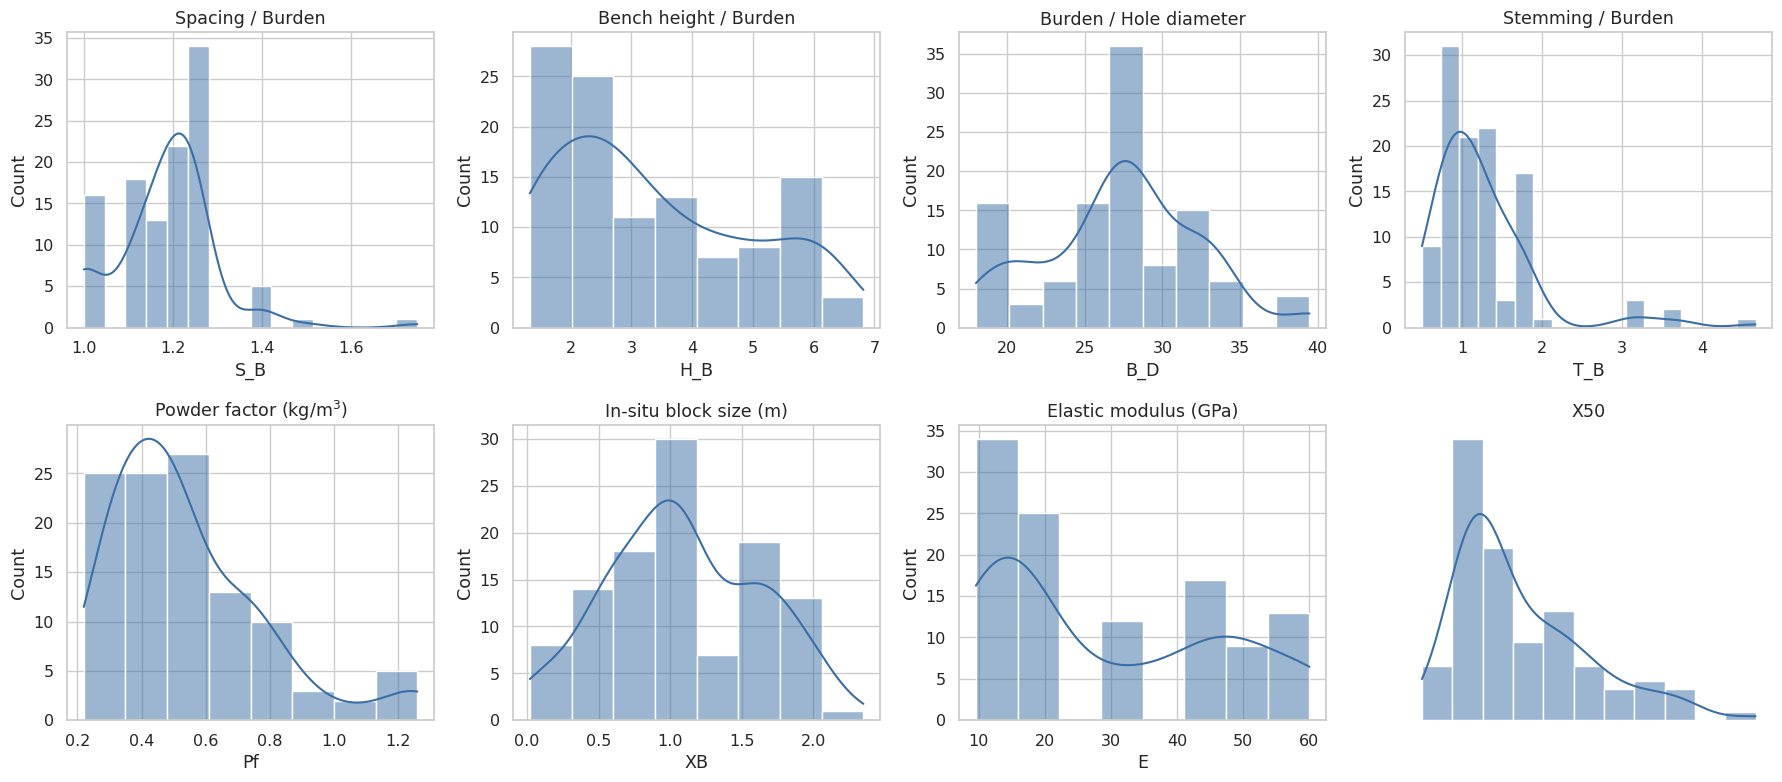

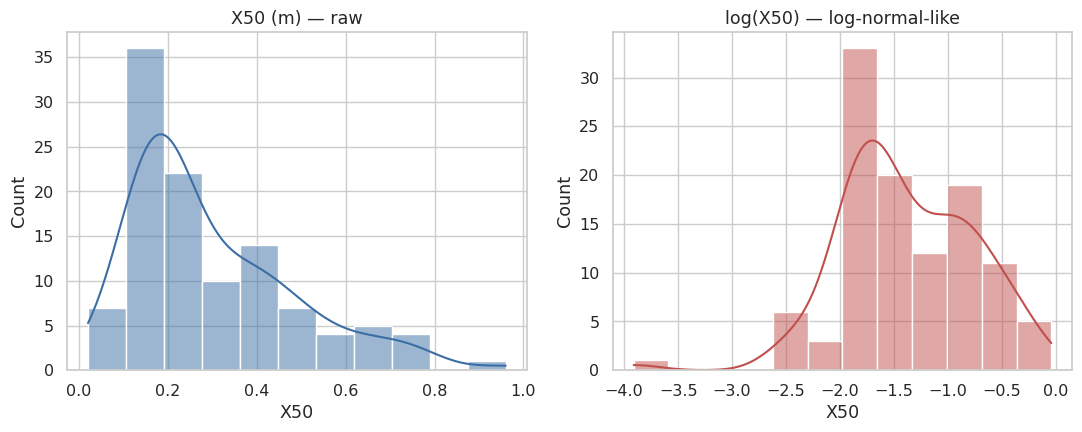

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, f in zip(axes.ravel(), FEATURES + [TARGET]):
    sns.histplot(df[f], kde=True, ax=ax, color="#3b6ea5")
    ax.set_title(FEATURE_LABELS.get(f, f))
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(OUT / "figures/F_hist_all.png", dpi=300)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sns.histplot(df[TARGET], kde=True, ax=ax[0], color="#3b6ea5")
ax[0].set_title("X50 (m) — raw")
sns.histplot(np.log(df[TARGET]), kde=True, ax=ax[1], color="#c0504d")
ax[1].set_title("log(X50) — log-normal-like")
plt.tight_layout()
plt.savefig(OUT / "figures/F2_target_distribution.png", dpi=300)
plt.show()

# ## 1.4 Correlation structure (Pearson + Spearman) — Figure 3 of the paper

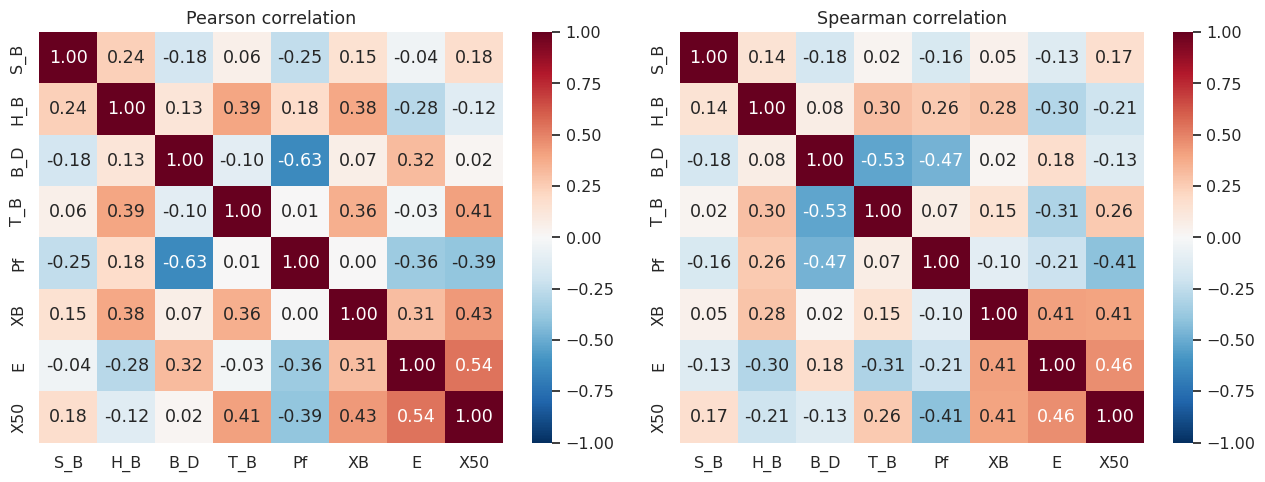

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(df[FEATURES + [TARGET]].corr("pearson"), annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Pearson correlation")
sns.heatmap(df[FEATURES + [TARGET]].corr("spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("Spearman correlation")
plt.tight_layout()
plt.savefig(OUT / "figures/F3_correlation.png", dpi=300)
plt.show()

# ## 1.5 X50 vs. each input, coloured by mine site
# Shows the **site-clustering** problem: several inputs (especially `E`,
# `B_D`) are nearly constant within a site, so a model can partly
# "recognise the mine" instead of learning the blast physics. This motivates
# the leave-one-site-out protocol in Phase 2.

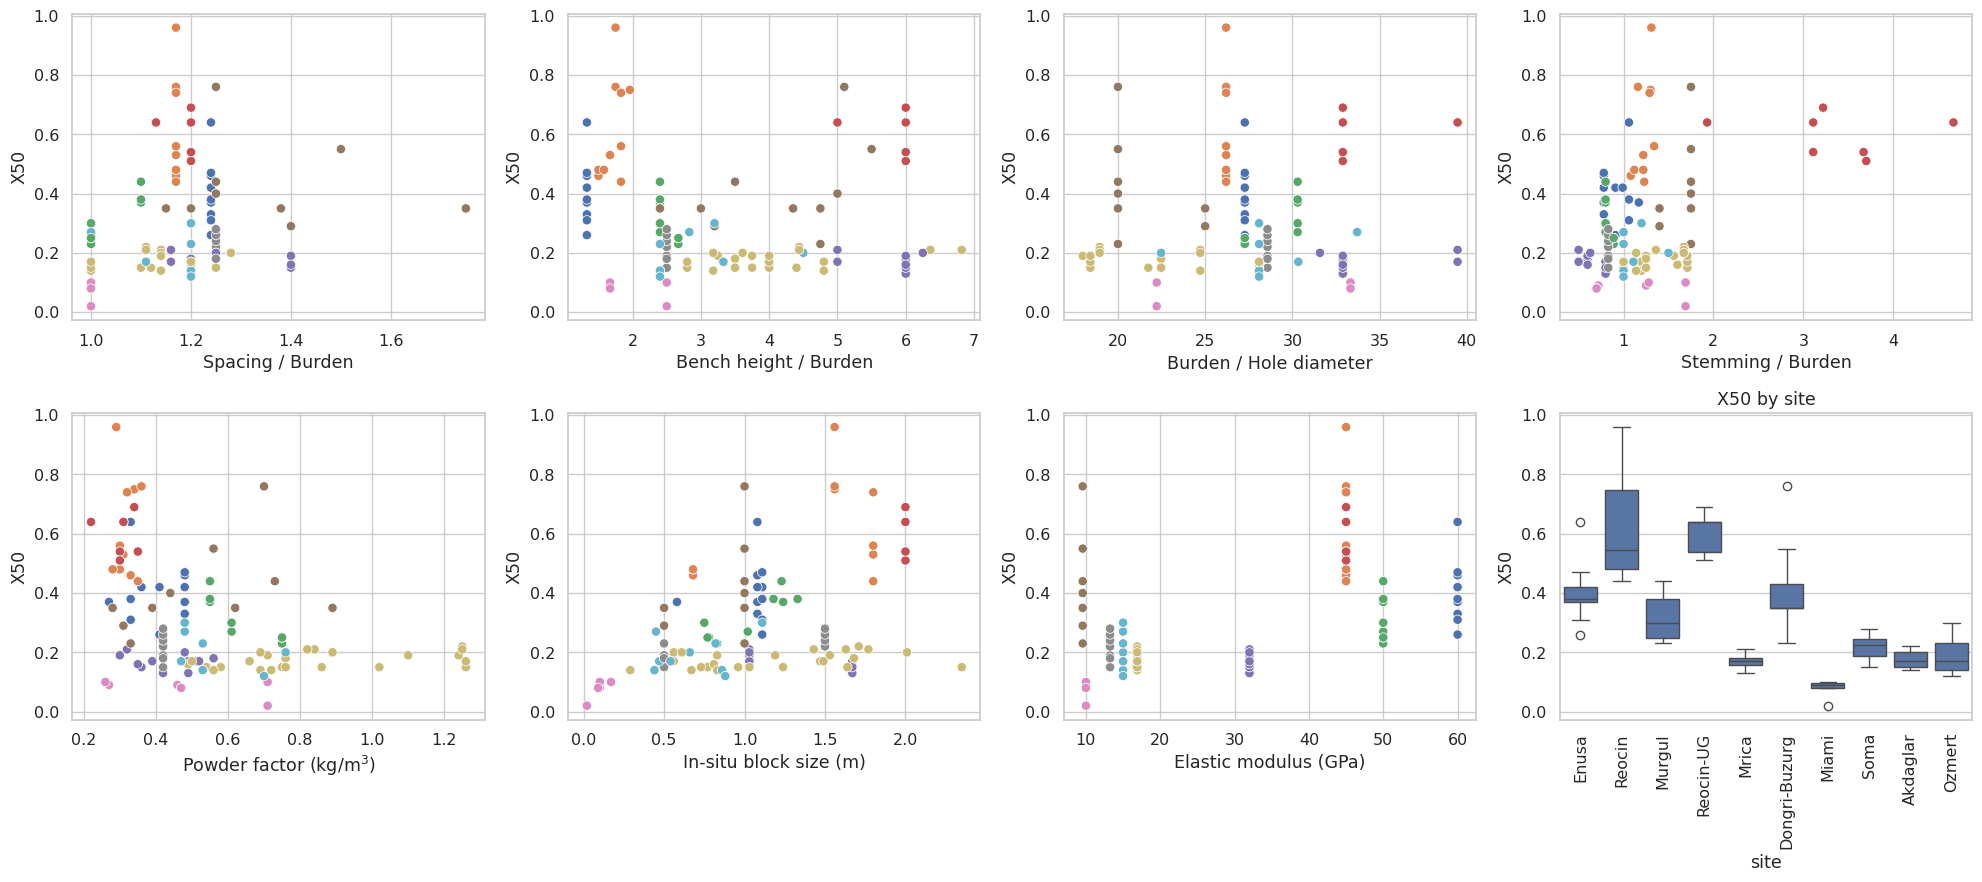

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, f in zip(axes.ravel(), FEATURES):
    sns.scatterplot(data=df, x=f, y=TARGET, hue="site", ax=ax, s=45, legend=False)
    ax.set_xlabel(FEATURE_LABELS.get(f, f))
sns.boxplot(data=df, x="site", y=TARGET, ax=axes.ravel()[-1])
axes.ravel()[-1].tick_params(axis="x", rotation=90)
axes.ravel()[-1].set_title("X50 by site")
handles, labels = axes[0, 0].get_legend_handles_labels()
plt.tight_layout()
plt.savefig(OUT / "figures/F4_scatter_by_site.png", dpi=300)
plt.show()

# ## 1.6 Multicollinearity (VIF)
# `statsmodels` is preinstalled on Kaggle.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xz = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
vif = pd.Series(
    {f: variance_inflation_factor(Xz.values, i) for i, f in enumerate(FEATURES)}, name="VIF"
).round(2)
vif.to_csv(OUT / "tables/T1b_vif.csv")
vif

S_B    2.14
H_B    2.87
B_D    3.95
T_B    1.58
Pf     3.84
XB     1.63
E      1.69
Name: VIF, dtype: float64

# ## 1.7 Duplicate-input clusters → irreducible measurement noise
# Several blasts share **identical** blast-design inputs (same S/B, H/B,
# B/D, T/B, Pf, XB, E) but different measured X50 — this is natural
# measurement/field variability. The pooled within-cluster standard
# deviation is a **noise floor**: no model, however good, can beat this on
# average, and it must be quoted alongside the benchmark RMSE in the paper.

In [8]:
dup = df.groupby(FEATURES)[TARGET].agg(["count", "std", "mean"]).query("count > 1")
noise_floor = float(np.sqrt((dup["std"] ** 2).mean()))
print(f"{len(dup)} duplicate-input clusters covering {dup['count'].sum()} blasts")
print(f"Irreducible noise floor (pooled within-cluster std of X50) = {noise_floor:.4f} m")
pd.Series({"n_clusters": len(dup), "n_blasts": int(dup["count"].sum()),
           "noise_floor_m": noise_floor}).to_csv(OUT / "tables/T1c_noise_floor.csv")
dup

8 duplicate-input clusters covering 20 blasts
Irreducible noise floor (pooled within-cluster std of X50) = 0.0586 m


count       std    mean
S_B  H_B  B_D   T_B  Pf   XB   E                             
1.20 6.00 32.89 0.80 0.49 1.67 32.00      2  0.028284  0.1500
1.24 1.33 27.27 0.78 0.48 0.58 60.00      2  0.000000  0.3700
                          1.08 60.00      2  0.091924  0.3950
                          1.11 60.00      2  0.035355  0.4450
                0.91 0.41 1.11 60.00      2  0.113137  0.3400
                1.06 0.33 1.11 60.00      2  0.049497  0.3450
1.25 2.50 28.57 0.83 0.42 0.50 13.25      4  0.033040  0.1875
                          1.50 13.25      4  0.025820  0.2500

# ## 1.8 Outlier screening (report only — do not delete; n=110 is small)

In [9]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(random_state=42, contamination=0.05).fit(df[FEATURES + [TARGET]])
df["iso_outlier"] = iso.predict(df[FEATURES + [TARGET]]) == -1
print(f"{df.iso_outlier.sum()} / {len(df)} flagged as potential outliers (Isolation Forest, 5%)")
df.loc[df.iso_outlier, ["blast_id", "site"] + FEATURES + [TARGET]]

6 / 110 flagged as potential outliers (Isolation Forest, 5%)


,blast_id,site,S_B,H_B,B_D,T_B,Pf,XB,E,X50
29,Ru1,Reocin-UG,1.13,5.00,39.47,1.93,0.31,2.00,45.00,0.64
32,Ru4,Reocin-UG,1.20,6.00,32.89,4.67,0.22,2.00,45.00,0.64
49,Db4,Dongri-Buzurg,1.50,5.50,20.00,1.75,0.56,1.00,9.57,0.55
50,Db5,Dongri-Buzurg,1.75,4.75,20.00,1.75,0.39,1.00,9.57,0.35
60,Mi6,Miami,1.00,2.50,22.22,1.69,0.71,0.02,10.00,0.02
98,Ru7,Reocin-UG,1.13,5.00,39.47,3.11,0.31,2.00,45.00,0.64


# ## 1.9 PCA projection coloured by site / elastic-modulus group

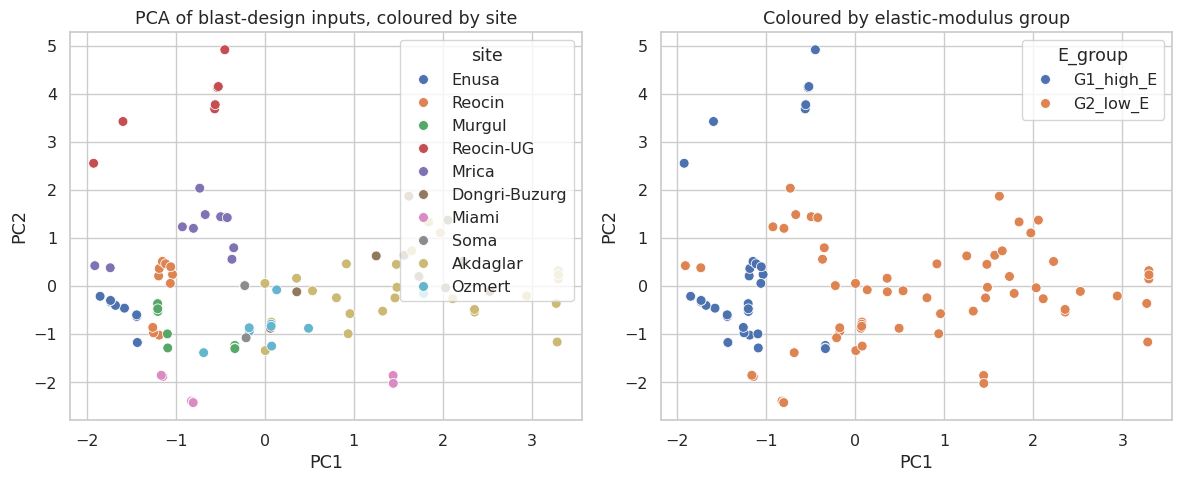

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pcs = PCA(n_components=2, random_state=42).fit_transform(StandardScaler().fit_transform(df[FEATURES]))
df["PC1"], df["PC2"] = pcs[:, 0], pcs[:, 1]
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="site", ax=ax[0], s=50)
ax[0].set_title("PCA of blast-design inputs, coloured by site")
sns.scatterplot(data=df, x="PC1", y="PC2", hue="E_group", ax=ax[1], s=50)
ax[1].set_title("Coloured by elastic-modulus group")
plt.tight_layout()
plt.savefig(OUT / "figures/F_pca.png", dpi=300)
plt.show()

# ## Outputs of this notebook
# - `tables/T1_descriptive.csv`, `T1b_vif.csv`, `T1c_noise_floor.csv`, `T2_sites.csv`
# - `figures/F2..F4, F_hist_all, F_pca`
#
# **Next:** commit this notebook, then either continue in the same notebook
# with `02_baselines_and_ml_benchmark.ipynb`'s cells, or start a fresh
# notebook and re-load `blast_master_110.csv` (EDA does not need to be
# re-run there).